In [1]:

import matplotlib.pyplot as plt
import numpy as np
from amocatlas import read
from scipy.stats import linregress, t

from correlation_trends import filters, geostrophy, analysis, trends

In [2]:
figpath = "../figures/"

In [3]:
## Read the datasets

# 26N transports: MOC, TRANS_FC, TRANS_EKMAN, TRANS_UMO
transports = read.rapid()

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)

# MOC = transports.MOC
# TRANS_FC = transports.TRANS_FC
# TRANS_EKMAN = transports.TRANS_FC
TRANS_UMO = transports.TRANS_UMO

# 26N boundary hydrography for Part 1 (TEMP_/PSAL_ WEST & EAST on PRESSURE)
ts = read.rapid(file_list=["ts_gridded.nc"], transport_only=False)
# 26N overturning in density coordinates: MOC_SIGMA0
# mt = read.rapid(file_list=["meridional_transports.nc"], transport_only=False)
# 47N NOAC overturning (monthly): MOC_SIGMA0
# noac = read.read_47n()

Loading 1 RAPID 26°N dataset(s):
  0. moc_transports.nc: RAPID layer transport time series

Loading 1 RAPID 26°N dataset(s):
  0. ts_gridded.nc: RAPID gridded temperature and salinity



In [4]:
transport = geostrophy.geostrophy_jakob(ts)
# introduce 10 day lowpass to match RAPID filtering
filtered_transport_geostrophy = filters.tukey_lowpass(transport, window=20)

In [5]:
print(analysis.summary_stats(transport)["mean"])
print(analysis.summary_stats(TRANS_UMO)["mean"])
print(analysis.summary_stats(transport)["std"])
print(analysis.summary_stats(TRANS_UMO)["std"])

-12.114512360823301
-18.36851235896635
6.1605249894137915
3.4169937749592694


In [6]:
print(analysis.summary_stats(transport)["mean"] - analysis.summary_stats(TRANS_UMO)["mean"])
print(analysis.summary_stats(transport)["std"] - analysis.summary_stats(TRANS_UMO)["std"])

6.253999998143048
2.743531214454522


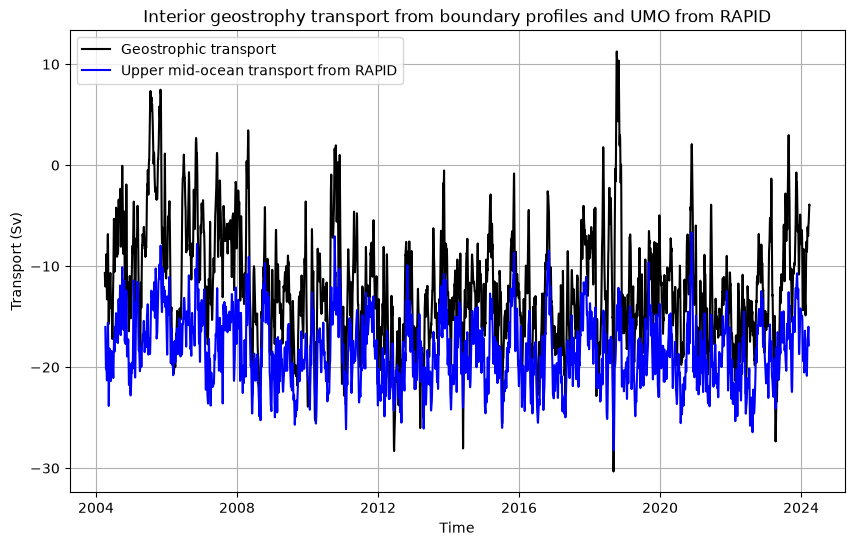

In [7]:
plt.figure(figsize=[10, 6])
plt.title("Interior geostrophy transport from boundary profiles and UMO from RAPID")
plt.plot(
    TRANS_UMO["TIME"],
    filtered_transport_geostrophy,
    color="k",
    label="Geostrophic transport",
)
plt.plot(
    TRANS_UMO["TIME"],
    TRANS_UMO,
    color="blue",
    label="Upper mid-ocean transport from RAPID",
)
plt.grid()
plt.xlabel("Time")
plt.ylabel("Transport (Sv)")
plt.legend()
plt.savefig(figpath + "UMO_geostrophy.png")

In [8]:
# we skip the first and last 10 time data points as they are removed in the 10 day lowpass filtering
finite_transport = np.isfinite(TRANS_UMO.values)
r = np.corrcoef(
    filtered_transport_geostrophy[finite_transport], TRANS_UMO.values[finite_transport]
)
r_unfiltered = np.corrcoef(
    transport[finite_transport], TRANS_UMO.values[finite_transport]
)

regression_line = linregress(
    filtered_transport_geostrophy[finite_transport], TRANS_UMO[finite_transport]
)
print(
    f"The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is {r[0, 1]:.3f}"
)
print(
    f"The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is {r_unfiltered[0, 1]:.3f}"
)

The correlation coefficient between the UMO transport from RAPID and our 10-day lowpassed calculated geostrophic transport is 0.773
The correlation coefficient between the UMO transport from RAPID and our unfiltered calculated geostrophic transport is 0.751


In [9]:
indices = np.argsort(filtered_transport_geostrophy[finite_transport])
ci_low, ci_up = trends.confband_not_timeseries(filtered_transport_geostrophy[finite_transport], TRANS_UMO[finite_transport])
geostrophy_sorted = (filtered_transport_geostrophy[finite_transport])[indices]
ci_low_sorted = ci_low[indices]
ci_up_sorted = ci_up[indices]

no xarray type, possibly already detrended
43


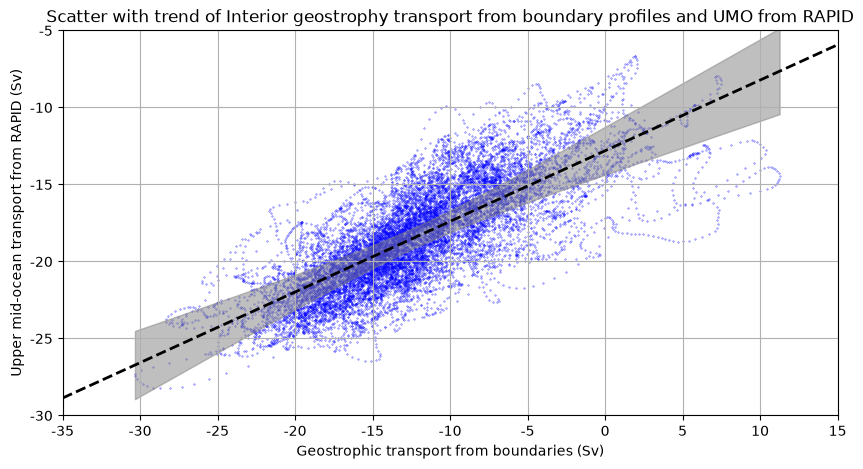

In [10]:
plt.figure(figsize=(10, 5))
plt.title("Scatter with trend of Interior geostrophy transport from boundary profiles and UMO from RAPID")
plt.scatter(
    filtered_transport_geostrophy, TRANS_UMO, c="blue", marker="x", s=1, alpha=0.3
)
plt.plot(
    np.arange(-35, 20, 5),
    np.arange(-35, 20, 5) * regression_line.slope + regression_line.intercept,
    ls="--",
    color="k",
    lw=2,
)
plt.fill_between(
    geostrophy_sorted,
    ci_low_sorted,
    ci_up_sorted,
    alpha=0.5,
    label="95% confidence band",
    color="grey",
)
plt.xlabel("Geostrophic transport from boundaries (Sv)")
plt.ylabel("Upper mid-ocean transport from RAPID (Sv)")
plt.grid()
plt.ylim(-30, -5)
plt.xlim(-35, 15)
plt.xticks(np.arange(-35, 20, 5), np.arange(-35, 20, 5))
plt.yticks(np.arange(-30, 0, 5), np.arange(-30, 0, 5))
plt.savefig(figpath + "scatter_geostrophy_UMO.png")
plt.show()

In [11]:
EDOF = np.min(
    np.array(
        [trends.effective_dof(filtered_transport_geostrophy[finite_transport],dt = 0.5),
        trends.effective_dof(TRANS_UMO[finite_transport],dt = 0.5)]
    )
)
p_eff = 2 * t.sf(np.abs(regression_line .slope / (regression_line.stderr * np.sqrt(TRANS_UMO[finite_transport].size / EDOF))), EDOF)
p_eff

no xarray type, possibly already detrended


np.float64(5.054173884806051e-10)